# Bank Customer Churn Prediction
This notebook aims to identify customers likely to leave the bank using the Churn Modelling dataset. We will perform data cleaning, encoding, and train a Random Forest model to analyze churn factors.

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load the dataset using a descriptive variable name
churn_df = pd.read_csv('/content/Churn_Modelling.csv')
display(churn_df.head())

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### 1. Data Cleaning and Preprocessing
We will drop unnecessary identifiers and encode categorical variables like 'Geography' and 'Gender'.

In [32]:
# Drop irrelevant columns and create a processed dataframe
churn_df_processed = churn_df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Encode Categorical features
le = LabelEncoder()
churn_df_processed['Gender'] = le.fit_transform(churn_df_processed['Gender'])

# One-hot encode Geography
churn_df_processed = pd.get_dummies(churn_df_processed, columns=['Geography'], drop_first=True)

display(churn_df_processed.head())

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


### 2. Model Training
We split the data and train a Random Forest Classifier to predict the 'Exited' column.

In [33]:
# Define features and target using the updated variable name
X = churn_df_processed.drop('Exited', axis=1)
y = churn_df_processed['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate the model
y_pred = rf_model.predict(X_test)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.87

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.77      0.46      0.57       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



### 3. Feature Importance
Finally, we visualize which features have the most influence on a customer's decision to leave.

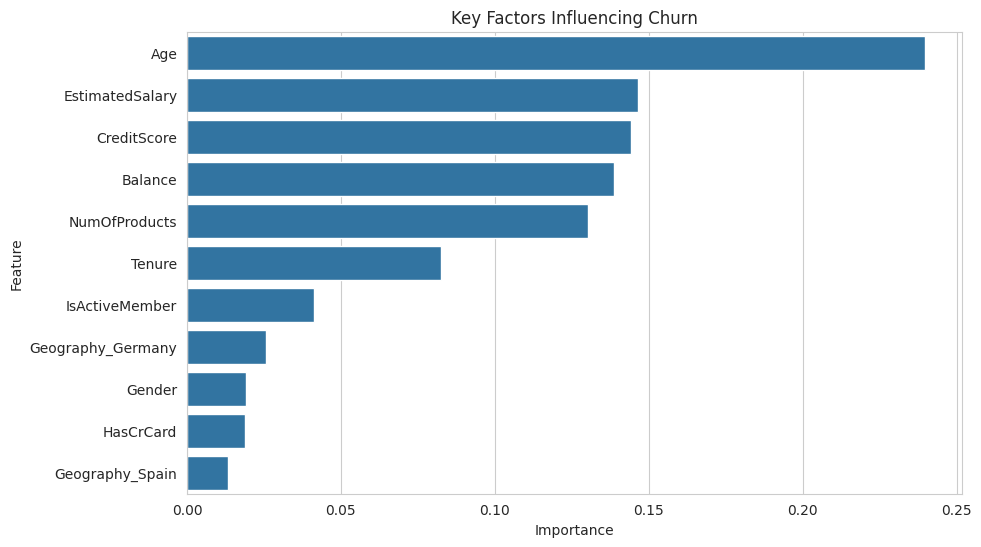

In [30]:
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Key Factors Influencing Churn')
plt.show()

## Final Summary and Accuracy Report

In this analysis, we successfully built a predictive model to identify bank customer churn.

### Model Results:
- **Classification Model:** Random Forest Classifier
- **Accuracy Score:** 0.87
- **Key Predictors:** Age, Estimated Salary, and Credit Score were identified as the most influential factors.

### Conclusion:
The model provides a strong baseline for identifying potential churners. Future improvements could include balancing the dataset to improve the recall for customers who actually exit (the '1' class).